<a href="https://colab.research.google.com/github/mishra2arya/Unsuppervised-learning/blob/main/wine_dataset_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Determine the optimal clustering configuration by applying Elbow Method, Silhouette Score,
and Davies–Bouldin Index on a dataset




In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

file_path = "/content/Wine dataset.csv"

df = pd.read_csv(file_path)

print("Dataset Overview:")
print(df.head())

X = df.select_dtypes(include=[np.number])
if 'Class' in X.columns:
    X = X.drop(columns=['Class'])
elif 'Customer_Segment' in X.columns:
    X = X.drop(columns=['Customer_Segment'])

# ==========================================
# 2. Feature Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. Clustering Metrics Evaluation
# ==========================================
k_range = range(2, 11)
inertias = []
silhouette_scores = []
db_indices = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))




Dataset Overview:
   class  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline   
0             5.64  1.04                          3.92      1065  
1     

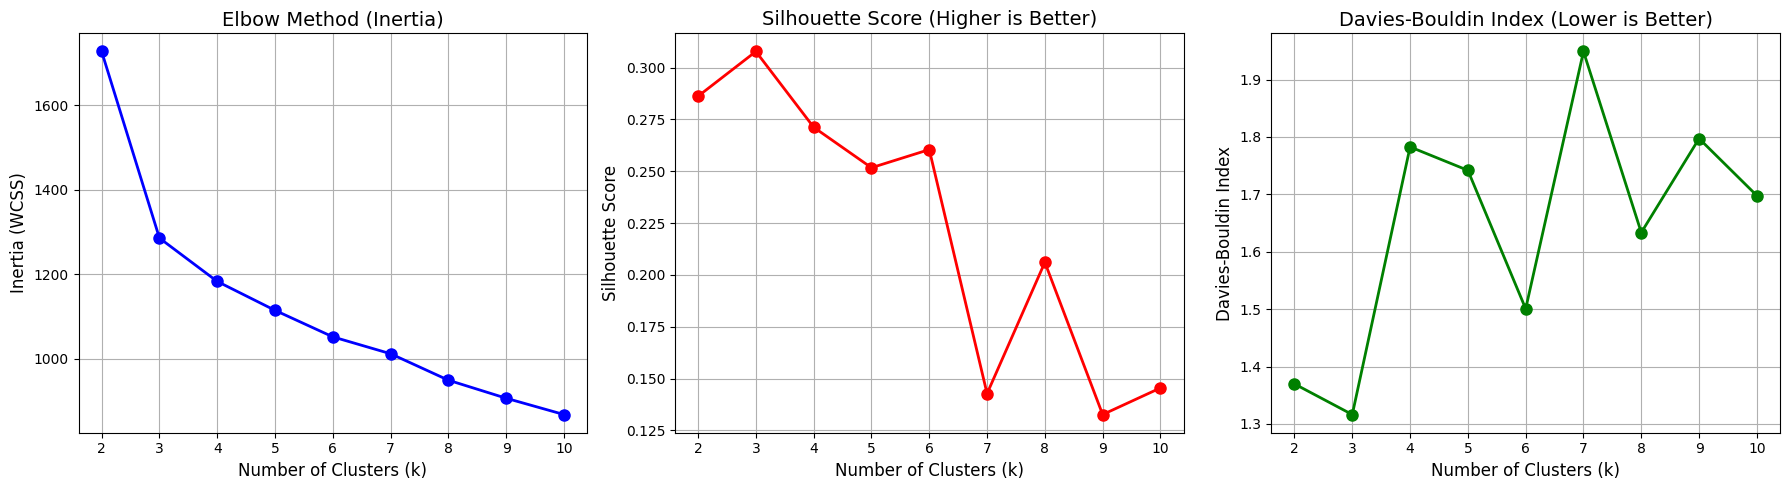

In [3]:
# ==========================================
# 4. Visualization
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Elbow Method (Inertia)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_xticks(k_range)
axes[0].grid(True)

# Plot 2: Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (Higher is Better)', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(k_range)
axes[1].grid(True)

# Plot 3: Davies-Bouldin Index
axes[2].plot(k_range, db_indices, 'go-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_xticks(k_range)
axes[2].grid(True)

plt.tight_layout()
plt.show()


In [4]:
# ==========================================
# 5. Output Results Summary
# ==========================================
results_df = pd.DataFrame({
    'Clusters (k)': list(k_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': db_indices
})

print("\nEvaluation Metrics Table:")
print(results_df.to_string(index=False))

best_silhouette_k = k_range[np.argmax(silhouette_scores)]
best_db_k = k_range[np.argmin(db_indices)]

print(f"\n- Highest Silhouette Score: k = {best_silhouette_k} ({max(silhouette_scores):.4f})")
print(f"- Lowest Davies-Bouldin Index: k = {best_db_k} ({min(db_indices):.4f})")


Evaluation Metrics Table:
 Clusters (k)     Inertia  Silhouette Score  Davies-Bouldin Index
            2 1727.228661          0.286167              1.369738
            3 1285.562259          0.307736              1.316396
            4 1182.948470          0.271210              1.782635
            5 1114.505232          0.251684              1.741797
            6 1051.783181          0.260433              1.500659
            7 1011.773612          0.142752              1.948853
            8  949.172343          0.206061              1.633460
            9  906.451771          0.132638              1.797192
           10  867.854757          0.145481              1.697748

- Highest Silhouette Score: k = 3 (0.3077)
- Lowest Davies-Bouldin Index: k = 3 (1.3164)


Analyze hierarchical relationships in unlabelled data by constructing dendrograms and
comparing multiple linkage strategies using Hierarchical Clustering.


--- Cophenetic Correlation Coefficient ---
(Higher values close to 1.0 indicate better preservation of pairwise distances)

Ward       Linkage Cophenetic Correlation: 0.6623
Complete   Linkage Cophenetic Correlation: 0.5917
Average    Linkage Cophenetic Correlation: 0.7591
Single     Linkage Cophenetic Correlation: 0.5436


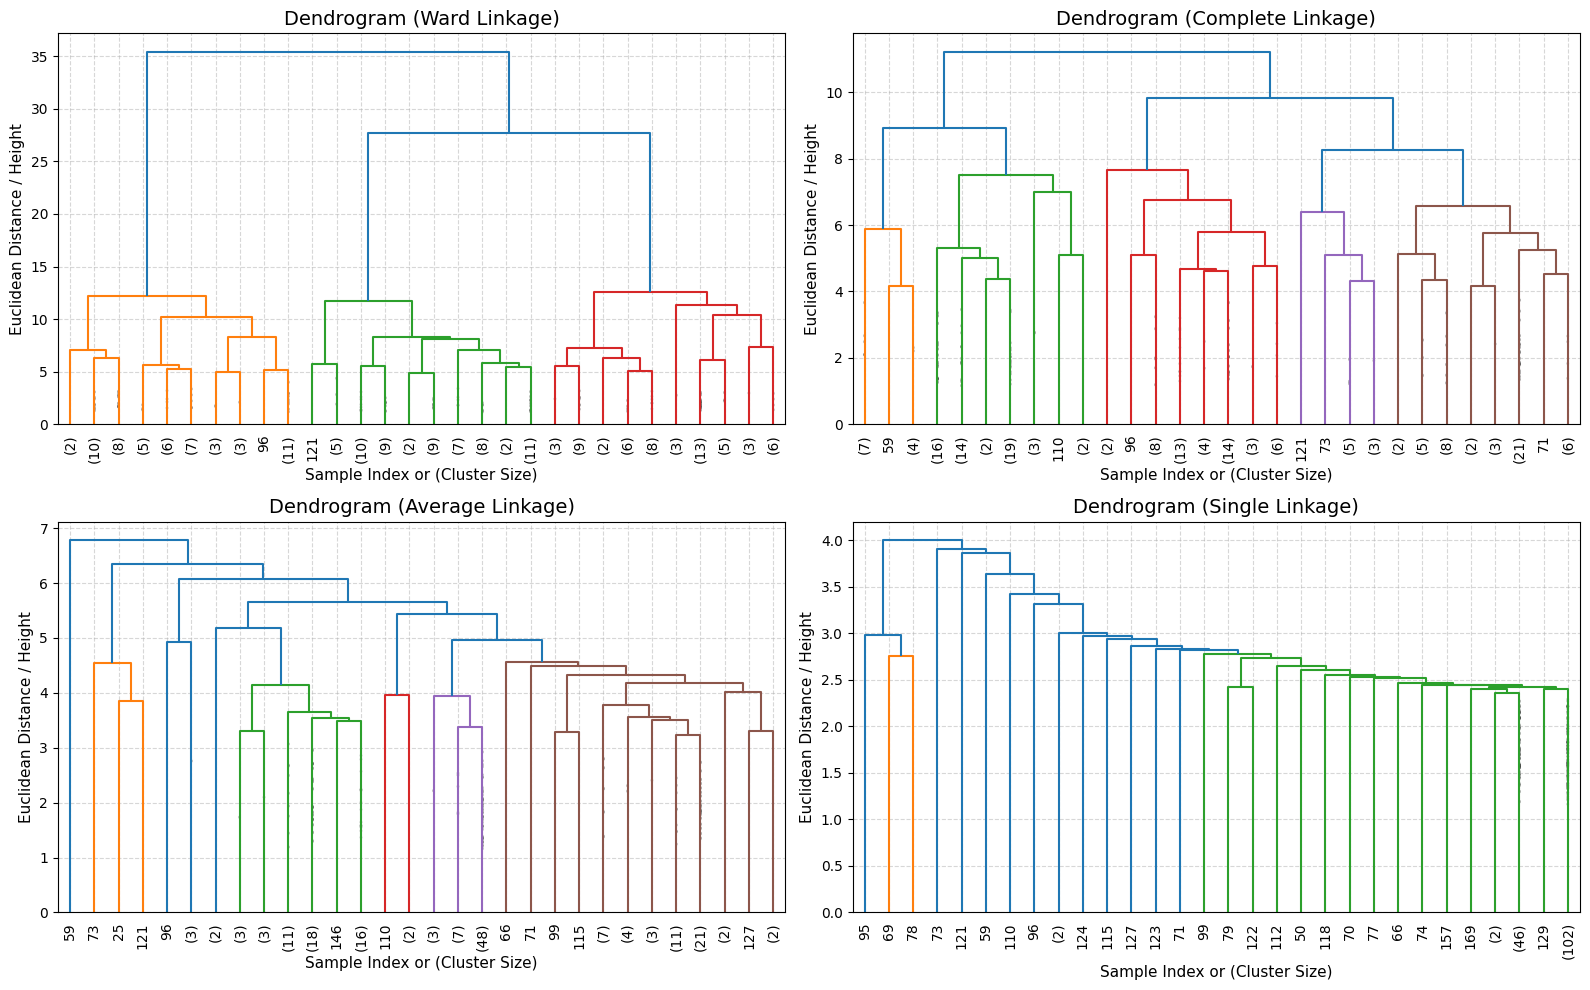


--- Clustering Metrics Comparison for k = 3 ---
Linkage Method  Silhouette Score (Higher is Better)  Davies-Bouldin Index (Lower is Better)
          Ward                               0.2774                                  1.4186
      Complete                               0.2038                                  1.8961
       Average                               0.1575                                  1.0299
        Single                               0.1827                                  0.9105


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score


file_path = "Wine dataset.csv"  # Ensure path matches your uploaded file name
df = pd.read_csv(file_path)

# Drop ground-truth/target labels or non-numeric columns for unlabeled analysis
X = df.select_dtypes(include=[np.number])
for col in ['class', 'Class', 'Customer_Segment']:
    if col in X.columns:
        X = X.drop(columns=[col])

# Feature scaling (essential for distance-based hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute condensed pairwise Euclidean distance matrix for cophenetic analysis
condensed_dist = pdist(X_scaled, metric='euclidean')

# ==========================================
# 2. Compare Linkage Strategies & Cophenetic Correlation
# ==========================================
linkage_methods = ['ward', 'complete', 'average', 'single']
linkage_matrix_dict = {}

print("--- Cophenetic Correlation Coefficient ---")
print("(Higher values close to 1.0 indicate better preservation of pairwise distances)\n")

for method in linkage_methods:
    # Compute hierarchical linkage
    Z = linkage(X_scaled, method=method)
    linkage_matrix_dict[method] = Z

    # Cophenetic correlation coefficient measures how faithfully a dendrogram preserves pairwise distances
    c, coph_dists = cophenet(Z, condensed_dist)
    print(f"{method.capitalize():<10} Linkage Cophenetic Correlation: {c:.4f}")





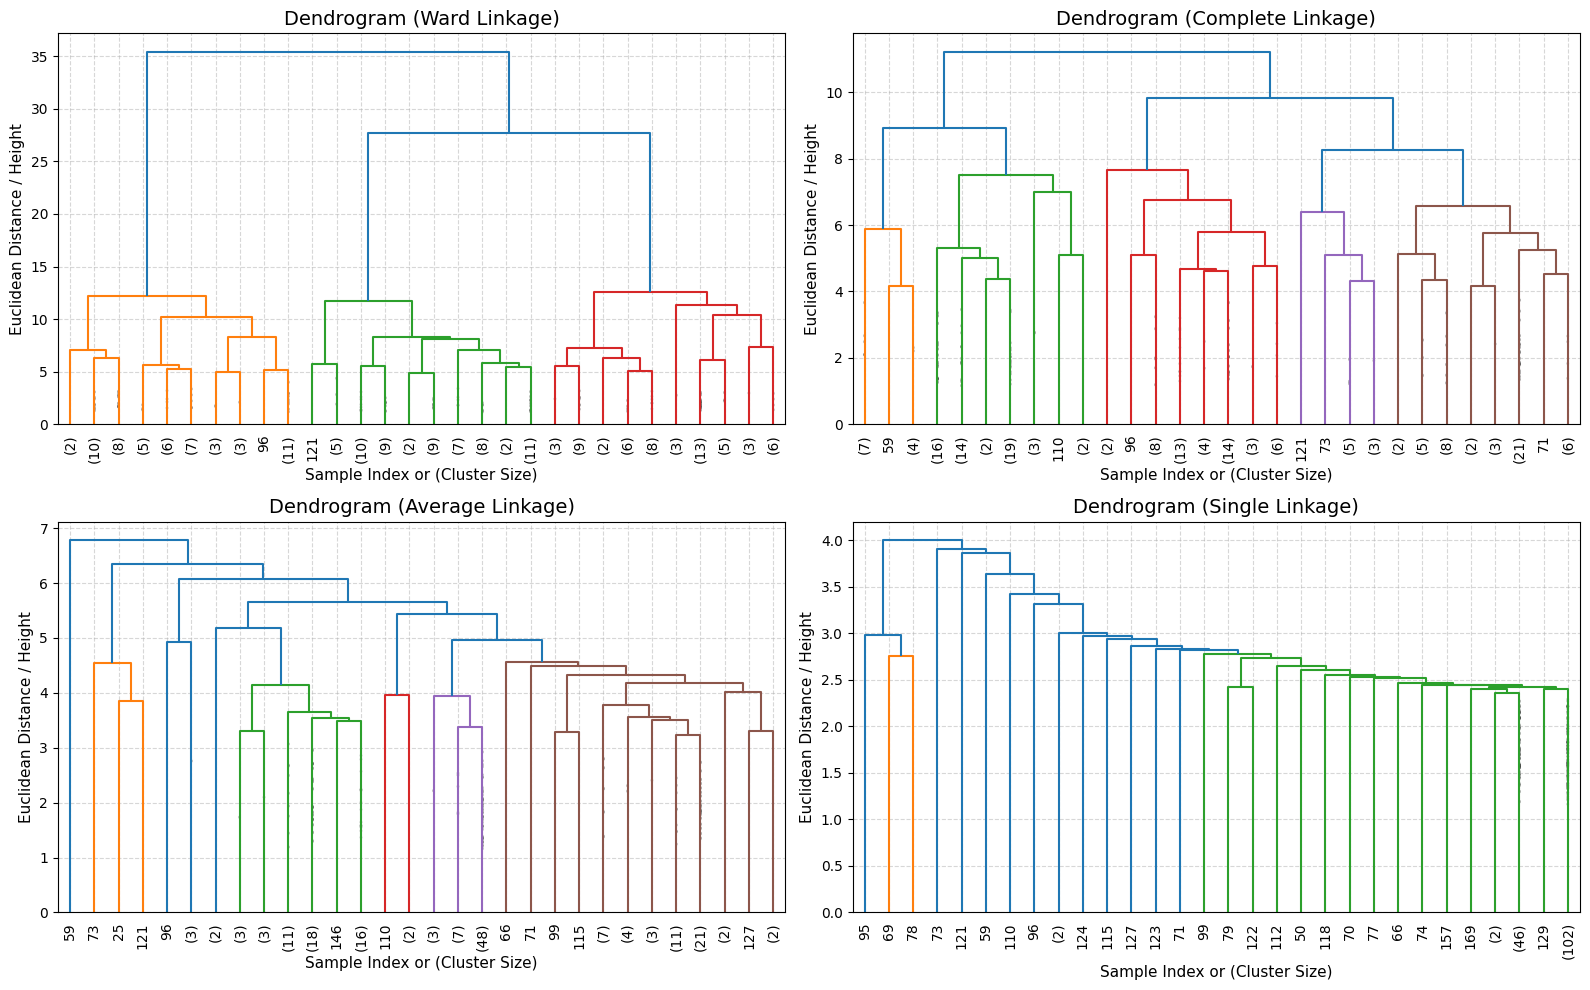

In [6]:
# ==========================================
# 3. Plot Dendrograms for All Linkage Methods
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, method in enumerate(linkage_methods):
    ax = axes[i]
    dendrogram(
        linkage_matrix_dict[method],
        ax=ax,
        truncate_mode='lastp',  # Summarize deep hierarchy
        p=30,                    # Show last p merged clusters
        leaf_rotation=90,
        leaf_font_size=10,
        show_contracted=True
    )
    ax.set_title(f"Dendrogram ({method.capitalize()} Linkage)", fontsize=14)
    ax.set_xlabel("Sample Index or (Cluster Size)", fontsize=11)
    ax.set_ylabel("Euclidean Distance / Height", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# 4. Compare Cluster Quality Metrics (Fixed k=3)
# ==========================================
# Note: 'ward' linkage strictly requires euclidean affinity in scikit-learn
results = []
n_clusters = 3

for method in linkage_methods:
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='euclidean',
        linkage=method
    )
    cluster_labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, cluster_labels)
    db = davies_bouldin_score(X_scaled, cluster_labels)

    results.append({
        'Linkage Method': method.capitalize(),
        'Silhouette Score (Higher is Better)': round(sil, 4),
        'Davies-Bouldin Index (Lower is Better)': round(db, 4)
    })

results_df = pd.DataFrame(results)
print(f"\n--- Clustering Metrics Comparison for k = {n_clusters} ---")
print(results_df.to_string(index=False))


--- Clustering Metrics Comparison for k = 3 ---
Linkage Method  Silhouette Score (Higher is Better)  Davies-Bouldin Index (Lower is Better)
          Ward                               0.3006                                  1.3264
      Complete                               0.1825                                  1.3492
       Average                               0.2709                                  1.0015
        Single                               0.1963                                  0.6405
